In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
%cd "/content/drive/My Drive/RUL_Prediction_CMAPSS_FD001_003/results"


/content/drive/My Drive/RUL_Prediction_CMAPSS_FD001_003/results


In [13]:
%cd "/content/drive/My Drive/RUL_Prediction_CMAPSS_FD001_003"

/content/drive/My Drive/RUL_Prediction_CMAPSS_FD001_003


In [14]:
!python results/supplementary_analysis.py

written results/comparison/supplementary_results.json
FD001 primary_rmse         diff=+0.942  MWU p=0.0091  Holm=0.0273  cliff=+0.70
FD001 primary_mae          diff=+0.040  MWU p=0.9698  Holm=0.9698  cliff=-0.02
FD001 primary_nasa_score   diff=+166.614  MWU p=0.0010  Holm=0.0060  cliff=+0.88
FD003 primary_rmse         diff=-0.545  MWU p=0.0257  Holm=0.0515  cliff=-0.60
FD003 primary_mae          diff=-1.072  MWU p=0.0022  Holm=0.0088  cliff=-0.82
FD003 primary_nasa_score   diff=+302.306  MWU p=0.0013  Holm=0.0066  cliff=+0.86
FD001 dRMSE 0.459 [-0.86, 1.786] | dMAE -0.571 [-1.657, 0.55] | dNASA 166.6 [13.6, 372.3]
FD003 dRMSE -1.296 [-3.21, 0.472] | dMAE -1.7 [-3.209, -0.184] | dNASA 302.3 [-128.8, 1084.7]


True RUL FD003 unit 16 = 56
Jarak ke kelompok RUL 40-80 : 3.92 | ke kelompok RUL>=100: 2.18


/tmp/ipykernel_1110/1173658881.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([mid[s], healthy[s]], labels=["RUL 40-80", "RUL>=100"], showfliers=False)
/tmp/ipykernel_1110/1173658881.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([mid[s], healthy[s]], labels=["RUL 40-80", "RUL>=100"], showfliers=False)
/tmp/ipykernel_1110/1173658881.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([mid[s], healthy[s]], labels=["RUL 40-80", "RUL>=100"], showfliers=False)
/tmp/ipykernel_1110/1173658881.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renam

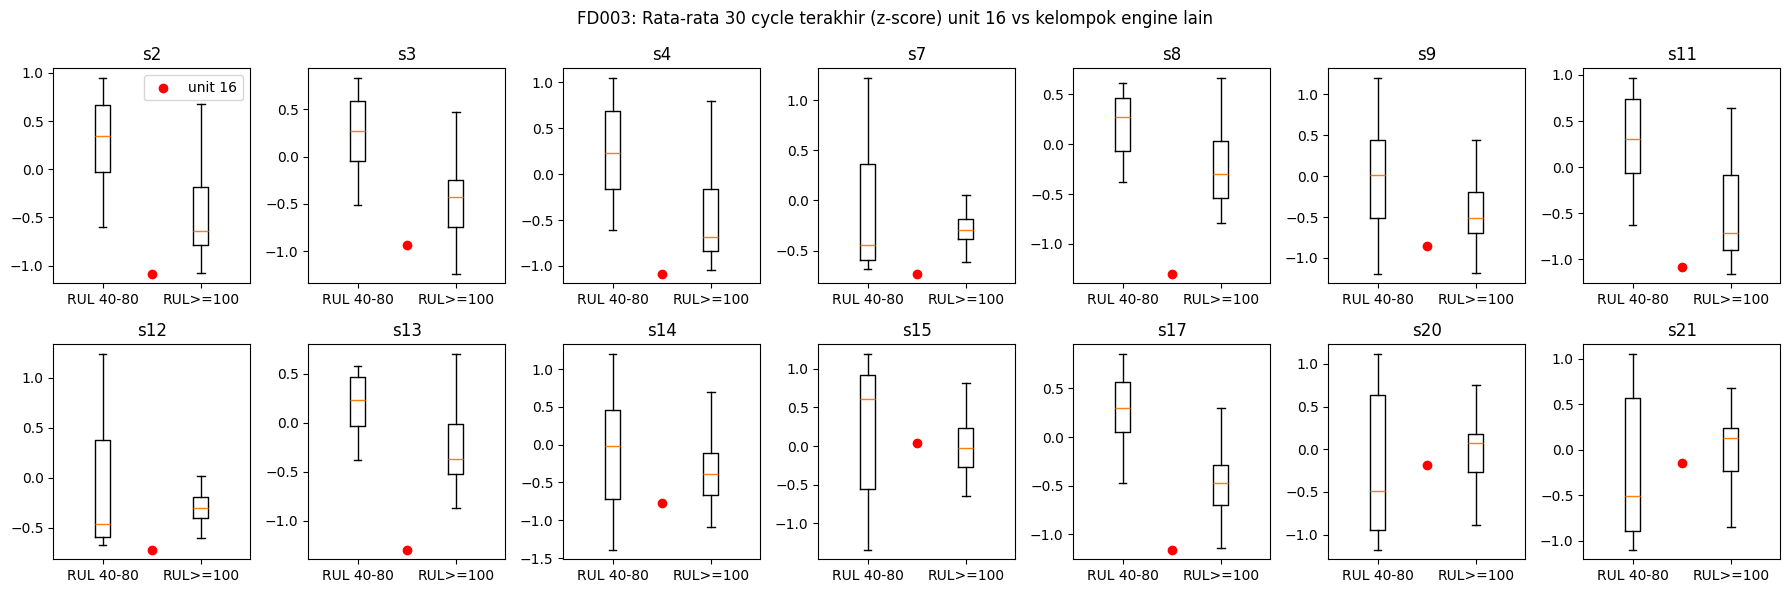

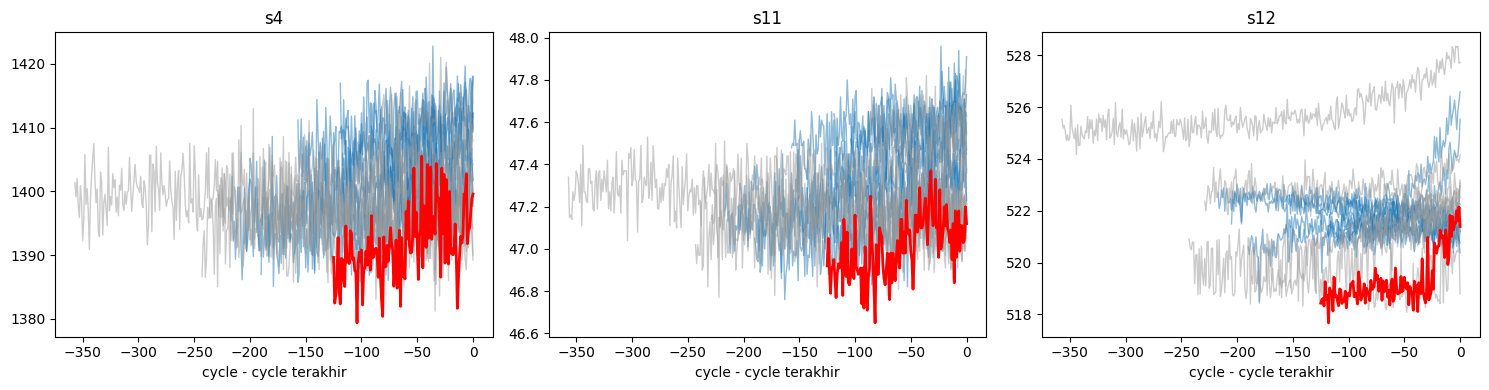

In [17]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

# Parameter Dataset: Pilih "FD003" atau "FD001"
ds = "FD003"

# Penentuan nama folder otomatis sesuai tangkapan layar Drive
if ds == "FD003":
    DATA_DIR = "RUL_Prediction_003"       # 1 underscore
    unit = 16
elif ds == "FD001":
    DATA_DIR = "RUL_Prediction__FD001"     # 2 underscore
    unit = 67

cols = ["unit","cycle","op1","op2","op3"] + [f"s{i}" for i in range(1,22)]
SENS = [f"s{i}" for i in [2,3,4,7,8,9,11,12,13,14,15,17,20,21]]

# Baca file .txt langsung dari folder Drive
tr  = pd.read_csv(f"{DATA_DIR}/train_{ds}.txt", sep=r"\s+", header=None, names=cols)
te  = pd.read_csv(f"{DATA_DIR}/test_{ds}.txt",  sep=r"\s+", header=None, names=cols)
rul = pd.read_csv(f"{DATA_DIR}/RUL_{ds}.txt", header=None)[0].values

print(f"True RUL {ds} unit {unit} =", rul[unit-1])

# 1) Hitung Z-Score dan Jarak Euclidean
mu, sd = tr[SENS].mean(), tr[SENS].std()
feat = te.groupby("unit").tail(30).groupby("unit")[SENS].mean()
z = (feat - mu) / sd
rul_s = pd.Series(rul, index=feat.index)
others = z.index != unit
mid = z[(rul_s >= 40) & (rul_s < 80) & others]
healthy = z[(rul_s >= 100) & others]

d_mid = np.linalg.norm(z.loc[unit] - mid.mean())
d_healthy = np.linalg.norm(z.loc[unit] - healthy.mean())
print(f"Jarak ke kelompok RUL 40-80 : {d_mid:.2f} | ke kelompok RUL>=100: {d_healthy:.2f}")

# 2) Visualisasi Boxplot Distribusi Sensor
fig, axes = plt.subplots(2, 7, figsize=(18, 6))
for ax, s in zip(axes.ravel(), SENS):
    ax.boxplot([mid[s], healthy[s]], labels=["RUL 40-80", "RUL>=100"], showfliers=False)
    ax.scatter([1.5], [z.loc[unit, s]], color="red", zorder=3, label=f"unit {unit}")
    ax.set_title(s)
axes[0,0].legend()
fig.suptitle(f"{ds}: Rata-rata 30 cycle terakhir (z-score) unit {unit} vs kelompok engine lain")
plt.tight_layout()
plt.show()

# 3) Visualisasi Trajektori Sensor
show = ["s4", "s11", "s12"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
rng = np.random.RandomState(0)
grp_mid = rng.choice(mid.index, min(10, len(mid)), replace=False)
grp_h   = rng.choice(healthy.index, min(10, len(healthy)), replace=False)

for ax, s in zip(axes, show):
    for u, c in [(g, "tab:blue") for g in grp_mid] + [(g, "0.6") for g in grp_h]:
        e = te[te.unit == u]
        ax.plot(e.cycle - e.cycle.max(), e[s], color=c, alpha=.5, lw=1)
    e = te[te.unit == unit]
    ax.plot(e.cycle - e.cycle.max(), e[s], color="red", lw=2)
    ax.set_title(s)
    ax.set_xlabel("cycle - cycle terakhir")

plt.tight_layout()
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/My Drive/RUL_Prediction_CMAPSS_FD001_003
=== RINGKASAN UNTUK TEXT PAPER (FD003 Unit 16) ===
True RUL: 56 | Observed cycles: 126
N engines: RUL 40-80 = 30, RUL >= 100 = 33
Dist to RUL 40-80 center: 3.92 | to RUL >= 100 center: 2.18
Sensors closer to healthy median than to mid median: 12/14
Sensors below healthy 5th percentile: 7/14 | inside healthy 5-95%: 7/14



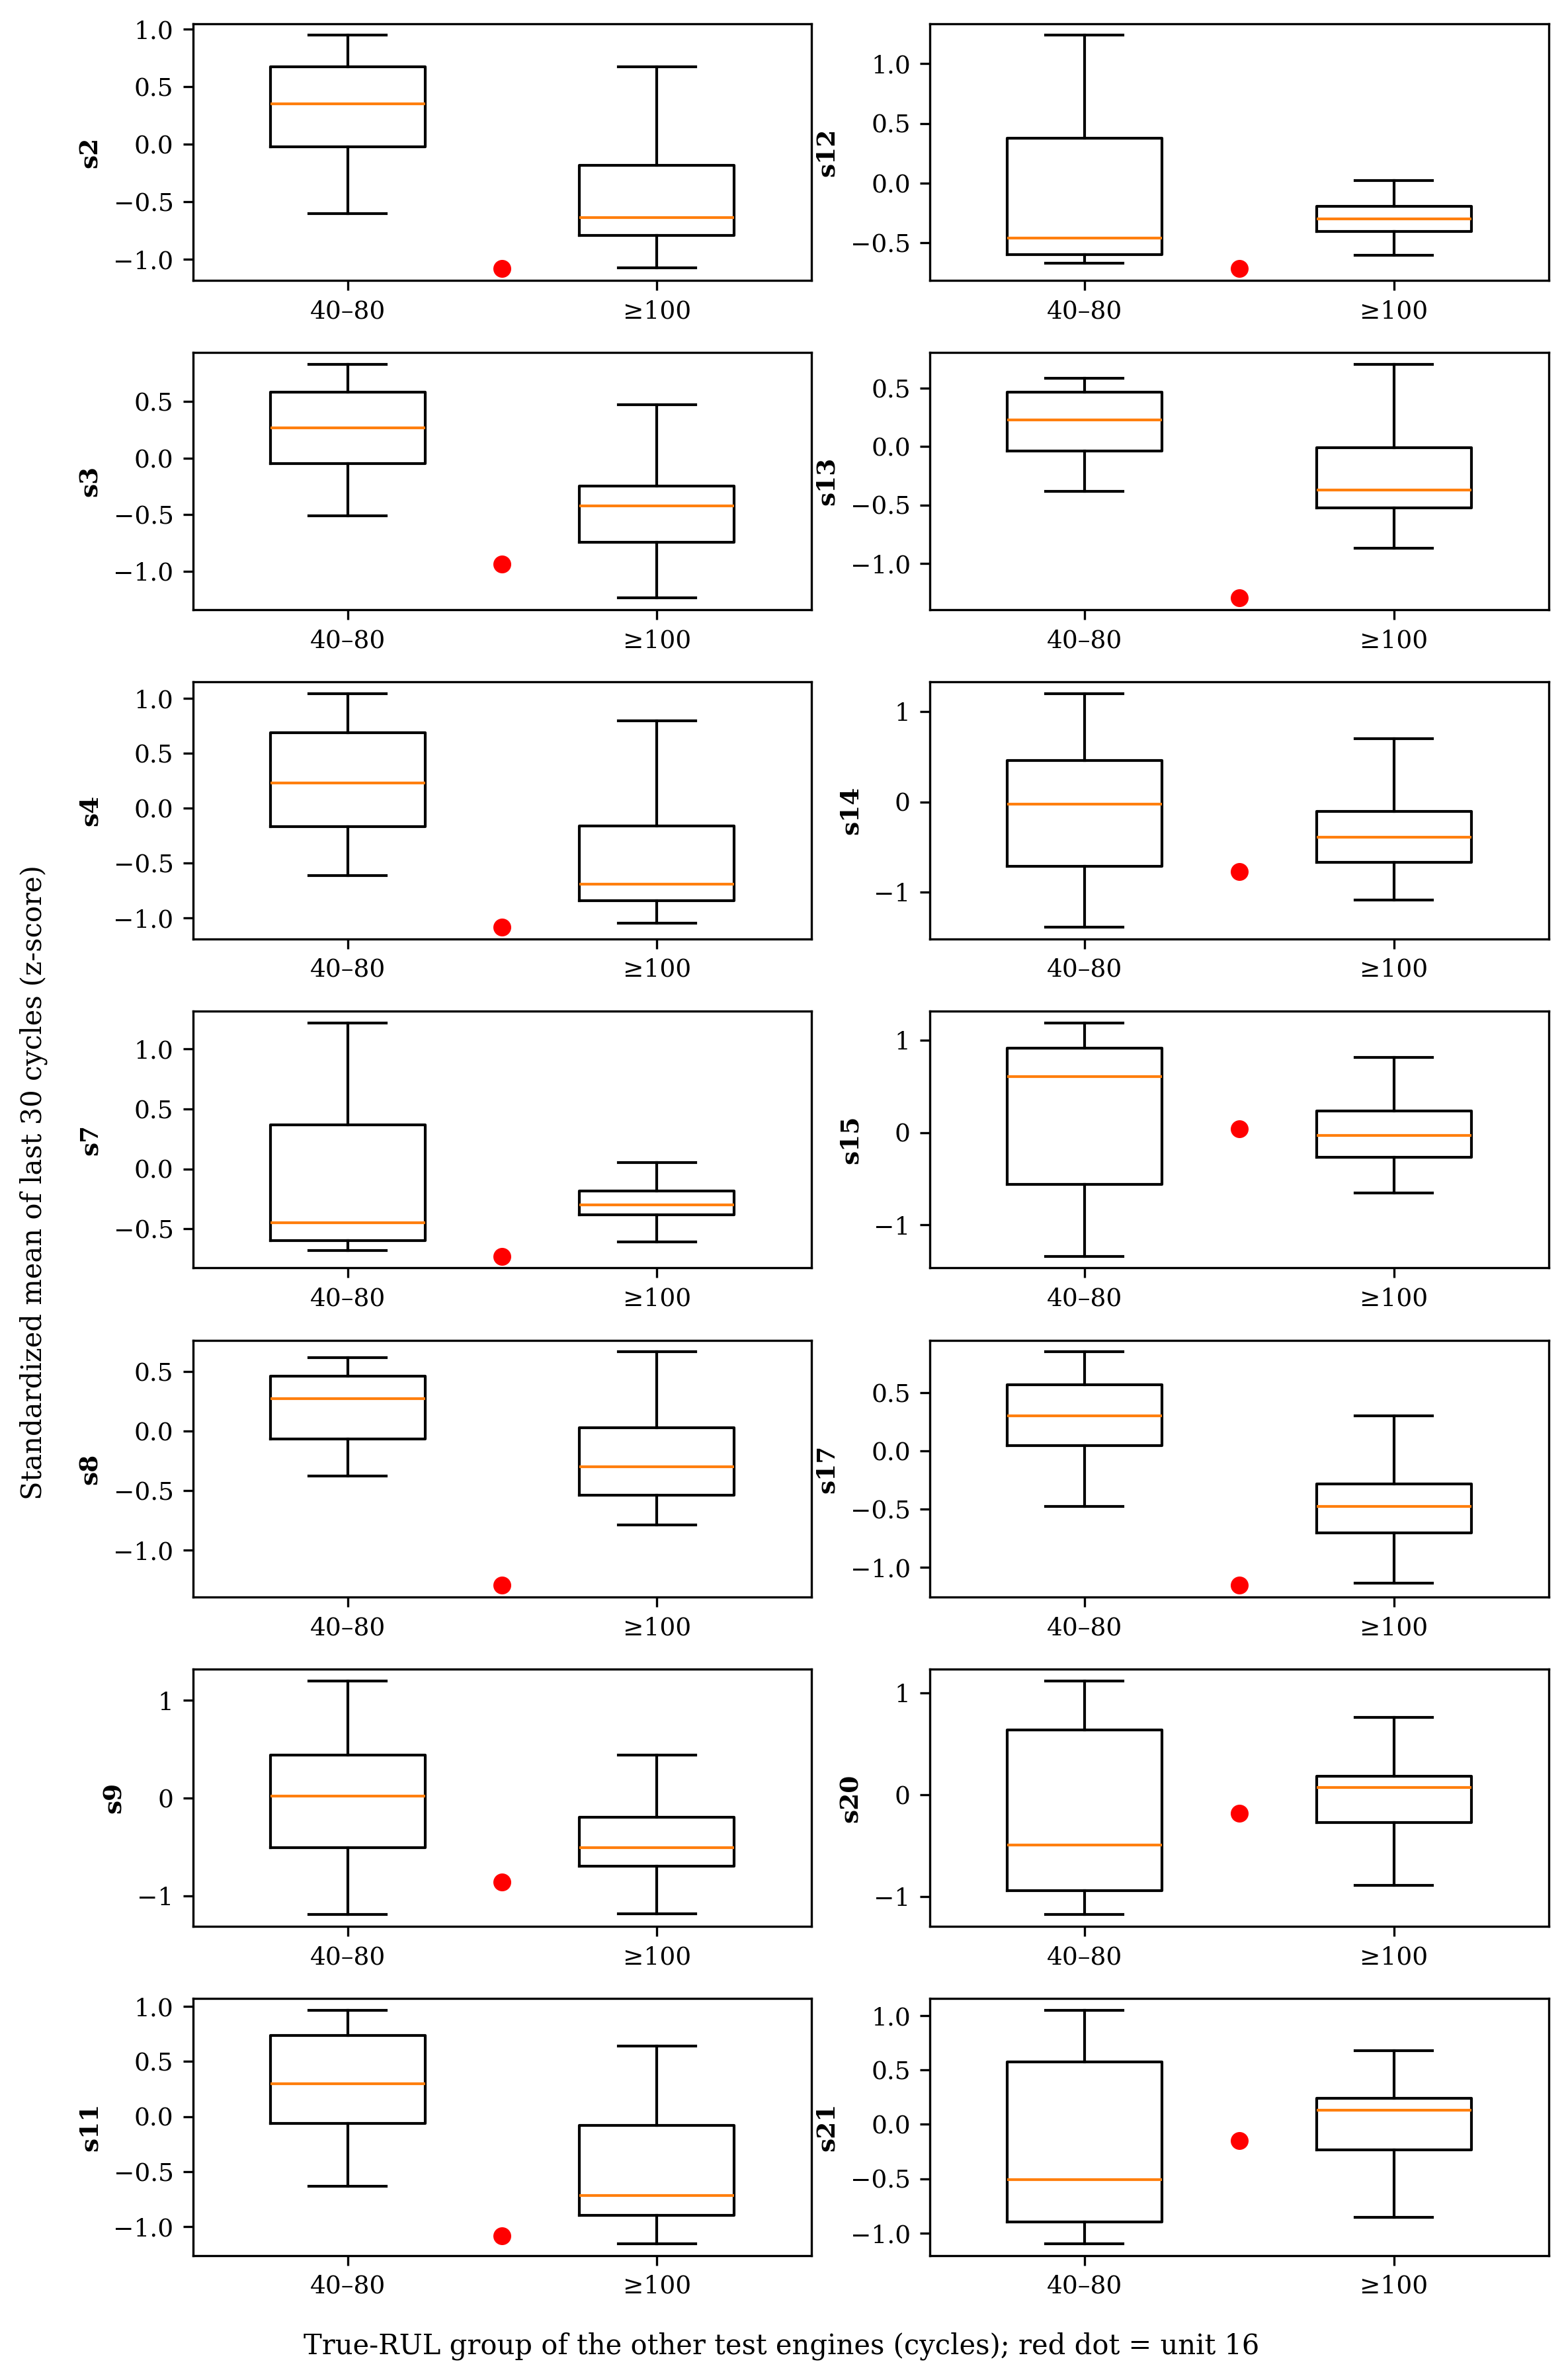

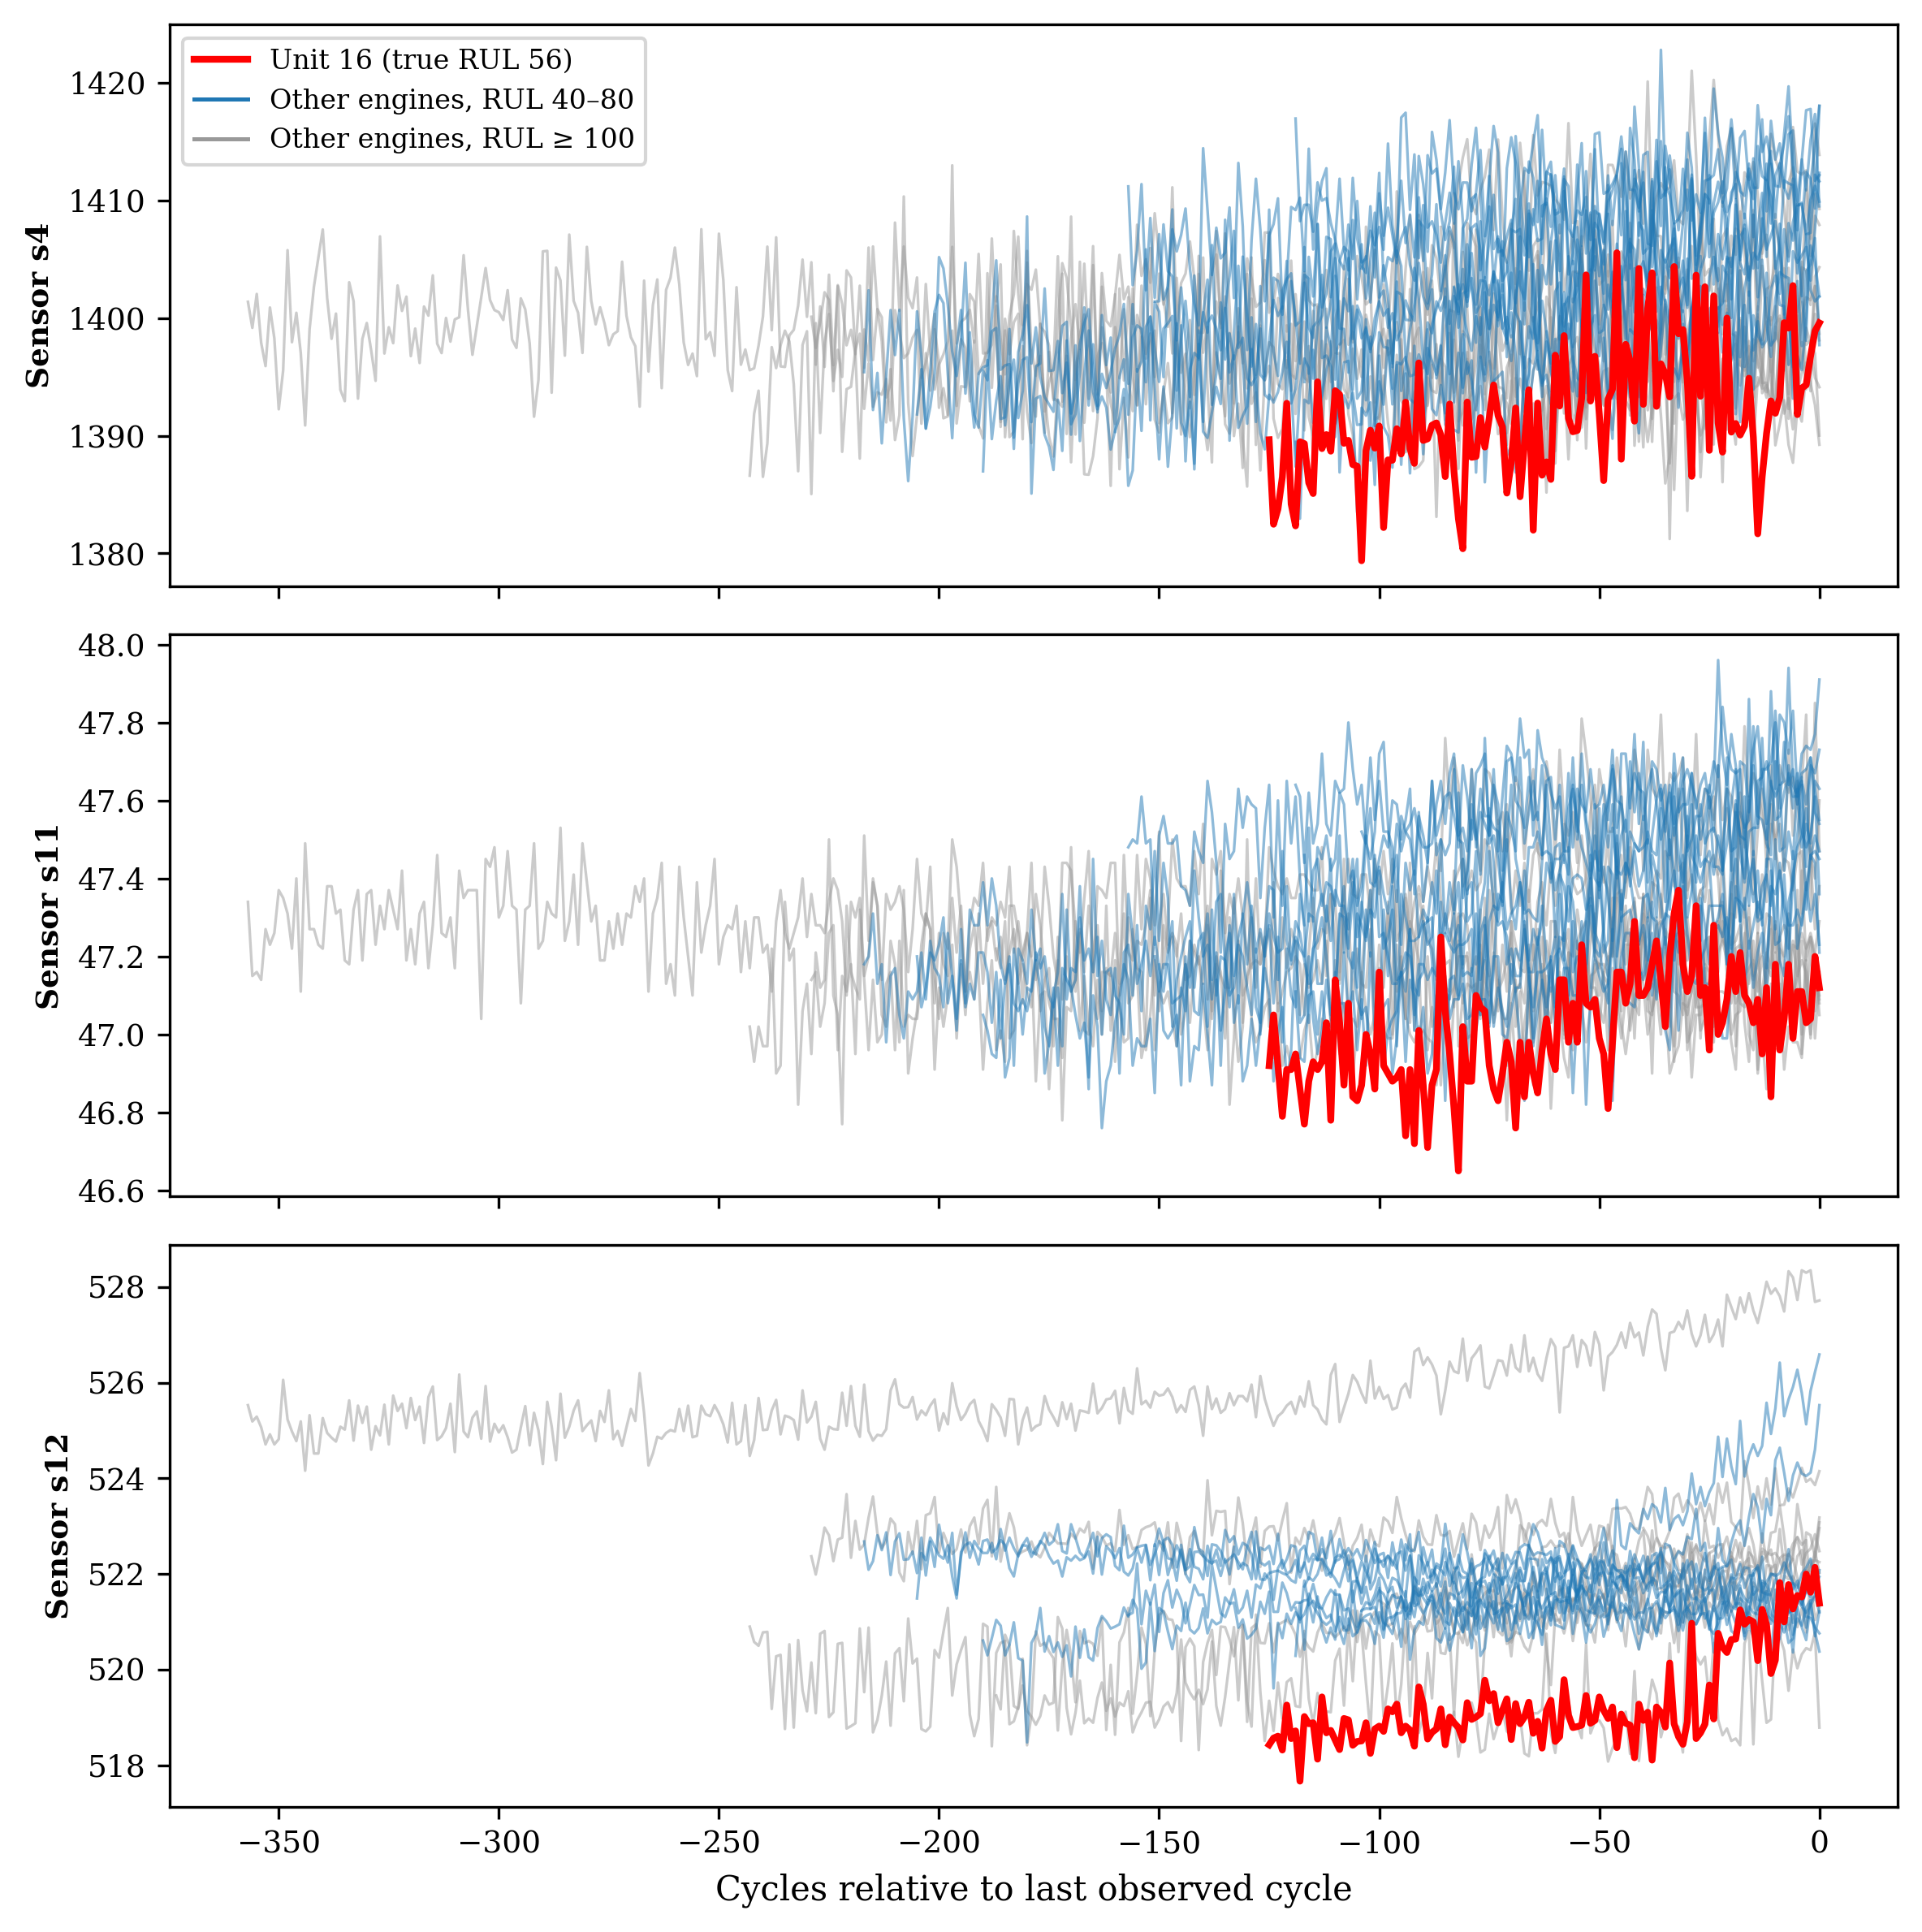

✅ Gambar HD khusus FD003 telah disimpan di: results/figures/


In [20]:
import os
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from google.colab import drive

# 1. Mount Drive & Pindah ke Root Directory Project
drive.mount('/content/drive', force_remount=False)
%cd "/content/drive/My Drive/RUL_Prediction_CMAPSS_FD001_003"

# Setup tampilan font & ukuran figur agar jernih dan tidak pecah
plt.rcParams.update({"font.size": 9, "font.family": "serif", "figure.dpi": 300})

# 2. Khusus Dataset FD003 & Unit 16
ds = "FD003"
DATA_DIR = "RUL_Prediction_003"
unit = 16

cols = ["unit","cycle","op1","op2","op3"] + [f"s{i}" for i in range(1,22)]
SENS = [f"s{i}" for i in [2,3,4,7,8,9,11,12,13,14,15,17,20,21]]

# 3. Baca Data
tr  = pd.read_csv(f"{DATA_DIR}/train_{ds}.txt", sep=r"\s+", header=None, names=cols)
te  = pd.read_csv(f"{DATA_DIR}/test_{ds}.txt",  sep=r"\s+", header=None, names=cols)
rul = pd.read_csv(f"{DATA_DIR}/RUL_{ds}.txt", header=None)[0].values

mu, sd = tr[SENS].mean(), tr[SENS].std()
feat = te.groupby("unit").tail(30).groupby("unit")[SENS].mean()
z = (feat - mu) / sd
rul_s = pd.Series(rul, index=feat.index)
others = z.index != unit
mid = z[(rul_s >= 40) & (rul_s < 80) & others]
healthy = z[(rul_s >= 100) & others]
zu = z.loc[unit]

# 4. Ringkasan Angka untuk Teks Paper
closer_h = int(((zu - healthy.median()).abs() < (zu - mid.median()).abs()).sum())
below_h5 = int((zu < healthy.quantile(0.05)).sum())
inside_h = int(((zu >= healthy.quantile(0.05)) & (zu <= healthy.quantile(0.95))).sum())

print("=== RINGKASAN UNTUK TEXT PAPER (FD003 Unit 16) ===")
print("True RUL:", rul[unit-1], "| Observed cycles:", int((te.unit == unit).sum()))
print(f"N engines: RUL 40-80 = {len(mid)}, RUL >= 100 = {len(healthy)}")
print(f"Dist to RUL 40-80 center: {np.linalg.norm(zu - mid.mean()):.2f} | to RUL >= 100 center: {np.linalg.norm(zu - healthy.mean()):.2f}")
print(f"Sensors closer to healthy median than to mid median: {closer_h}/14")
print(f"Sensors below healthy 5th percentile: {below_h5}/14 | inside healthy 5-95%: {inside_h}/14")
print("===================================================\n")

# Buat folder penyimpanan hasil jika belum ada
output_dir = "results/figures"
os.makedirs(output_dir, exist_ok=True)

# 5. Figure A: Sensor Levels (Ukuran diperbesar agar jernih & tajam)
fig, axes = plt.subplots(7, 2, figsize=(8, 12))
for ax, s in zip(axes.T.ravel(), SENS):
    ax.boxplot([mid[s], healthy[s]], showfliers=False, widths=0.5)
    ax.scatter([1.5], [zu[s]], color="red", s=30, zorder=3)
    ax.set_ylabel(s, fontsize=9, fontweight='bold')
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["40–80", "≥100"])

fig.text(0.5, 0.008, f"True-RUL group of the other test engines (cycles); red dot = unit {unit}", ha="center", fontsize=10)
fig.supylabel("Standardized mean of last 30 cycles (z-score)", fontsize=10)
plt.tight_layout(rect=(0.02, 0.02, 1, 1))

fig_a_path = f"{output_dir}/fig_unit16_sensor_levels.png"
fig.savefig(fig_a_path, dpi=300, bbox_inches="tight")
plt.show()

# 6. Figure B: Trajectories (Ukuran diperbesar agar jernih & tajam)
rng = np.random.RandomState(0)
gm = rng.choice(mid.index, min(10, len(mid)), replace=False)
gh = rng.choice(healthy.index, min(10, len(healthy)), replace=False)

fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
for ax, s in zip(axes, ["s4", "s11", "s12"]):
    for u in gh:
        e = te[te.unit == u]
        ax.plot(e.cycle - e.cycle.max(), e[s], color="0.6", alpha=.5, lw=.8)
    for u in gm:
        e = te[te.unit == u]
        ax.plot(e.cycle - e.cycle.max(), e[s], color="tab:blue", alpha=.5, lw=.8)
    e = te[te.unit == unit]
    ax.plot(e.cycle - e.cycle.max(), e[s], color="red", lw=2.0)
    ax.set_ylabel(f"Sensor {s}", fontsize=9, fontweight='bold')

axes[-1].set_xlabel("Cycles relative to last observed cycle", fontsize=10)
axes[0].legend(handles=[
    Line2D([0],[0], color="red", lw=2.0, label=f"Unit {unit} (true RUL {rul[unit-1]})"),
    Line2D([0],[0], color="tab:blue", lw=1.2, label="Other engines, RUL 40–80"),
    Line2D([0],[0], color="0.6", lw=1.2, label="Other engines, RUL ≥ 100")
], loc="upper left", fontsize=8)

plt.tight_layout()
fig_b_path = f"{output_dir}/fig_unit16_trajectories.png"
fig.savefig(fig_b_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"✅ Gambar HD khusus FD003 telah disimpan di: {output_dir}/")